# Nombre: Byron Ortiz

### Data Collection and Preprocessing

Work with the Caltech101 dataset. Preprocessing usually involves resizing the images to a consistent size and normalize the pixel values.

Se carga las siguientes librerias

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

Se carga el corpus de imagenes caltech101 al cual se preprocesa las imagenes de la data de entrenamiento y de testeo

In [3]:
(train_dataset, test_dataset), dataset_info = tfds.load(
    name='caltech101',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True,
    data_dir='C:/Users/byron/Downloads/data_tensorflow_sets',
    download=False
)
def preprocess_image(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label
nombre_clases = dataset_info.features['label'].names
train_dataset = train_dataset.map(preprocess_image).shuffle(1000).batch(32)
test_dataset = test_dataset.map(preprocess_image).batch(32)

### Feature Extraction

Use a pre-trained CNN model (e.g., VGG16) to extract features from the images.

Remove the top layers to get the feature vectors.

Se carga el modelo preentrenado que se va a usar para extraer las caracteristicas de imagenes

In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
    
# Load the VGG16 model with pretrained weights from ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Create a new model that outputs the feature maps
model = Model(inputs=base_model.input, outputs=base_model.layers[-1].output)

Se extrae las caracteristicas de cada imagen del train y del test junto a sus imagenes y labels

In [6]:
# Function to extract features
def extract_features(dataset):
    features = []
    labels = []
    imagenes = []   
    for images, lbls in dataset:
        imagenes.append(images)
        feature_maps = model.predict(images)
        features.append(feature_maps)
        labels.append(lbls.numpy())
    return features, labels, imagenes

# Extract features for train and test datasets
train_features, train_labels,train_imagenes = extract_features(train_dataset)
test_features, test_labels,test_imagenes = extract_features(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 

### Indexing

Use an in-memory index using NumPy. Other alternatives are more scalable solutions like FAISS or an approximate nearest neighbor search library.

Se aplana los arrays para tener los vectores en una forma mas facil de manejar

In [7]:
# Flatten the feature maps to create feature vectors
train_features_flat = np.array([feature.flatten() for batch in train_features for feature in batch])
train_labels_flat = np.array([label for batch in train_labels for label in batch])
train_imagenes_flat = np.array([img for batch in train_imagenes for img in batch])
test_imagenes_flat = np.array([img for batch in test_imagenes for img in batch])

In [8]:
print('Train features shape:', train_features_flat.shape)
print('Train labels shape:', train_labels_flat.shape)
print('Train imagenes shape:', train_imagenes_flat.shape)
print('Test imagenes shape:', test_imagenes_flat.shape)

Train features shape: (3059, 25088)
Train labels shape: (3059,)
Train imagenes shape: (3059, 224, 224, 3)
Test imagenes shape: (6085, 224, 224, 3)


Se guarda los 4 arreglos en disco debido a que tarda un tiempo en generarse

In [11]:
np.save('datos/train_features.npy', train_features_flat)
np.save('datos/train_labels.npy', train_labels_flat)
np.save('datos/train_imgenes.npy', train_imagenes_flat)
np.save('datos/test_imgenes.npy', test_imagenes_flat)

Se carga los datos guardados en el paso anterior 

In [7]:
# Load the saved features and labels
train_features_flat = np.load('datos/train_features.npy')
train_labels_flat = np.load('datos/train_labels.npy')
train_imgenes_flat = np.load('datos/train_imgenes.npy')
test_imgenes_flat = np.load('datos/test_imgenes.npy')

se carga el modelo nearestneighbors para hacer la busqueda de caracteristicas similares

In [5]:
# Example query: Retrieve the 5 nearest neighbors for a test image
from sklearn.neighbors import NearestNeighbors

# Fit the NearestNeighbors model
nn_model = NearestNeighbors(n_neighbors=10, algorithm='ball_tree').fit(train_features_flat)

Se carga y se muestr la imagen que queremos hacer la consulta

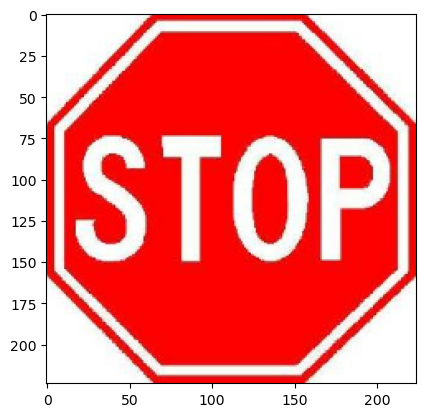

In [8]:
query_image = test_imgenes_flat[1]
query_image = tf.expand_dims(query_image, axis=0)  # Add batch dimension
plt.imshow(query_image[0])

Se obtiene las caracteristicas de la imagen usando el modelo que ya teniamos

In [11]:
query_features = model.predict(query_image).flatten().reshape(1, -1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step


Se encuentra los vecinos mas cercanos a las caracteristicas de la imagen que estamos consultando

In [12]:
# Find the nearest neighbors
distances, indices = nn_model.kneighbors(query_features)
print("Indices of nearest neighbors:", indices)
print("Distances to nearest neighbors:", distances)

Indices of nearest neighbors: [[ 787 1962 2420 1044  303 2695 2269  704 2882 2902]]
Distances to nearest neighbors: [[ 6.74055127  7.04572166 17.01815726 22.58662163 28.70876336 29.41278678
  33.61844146 35.29428446 36.22556807 36.44891582]]


se usa los indices para buscar la label y a que imagen pertenece cada caracteristica y asi poder mostrarla en pantalla las imagenes con caracteristicas mas cercanas a la de la consulta

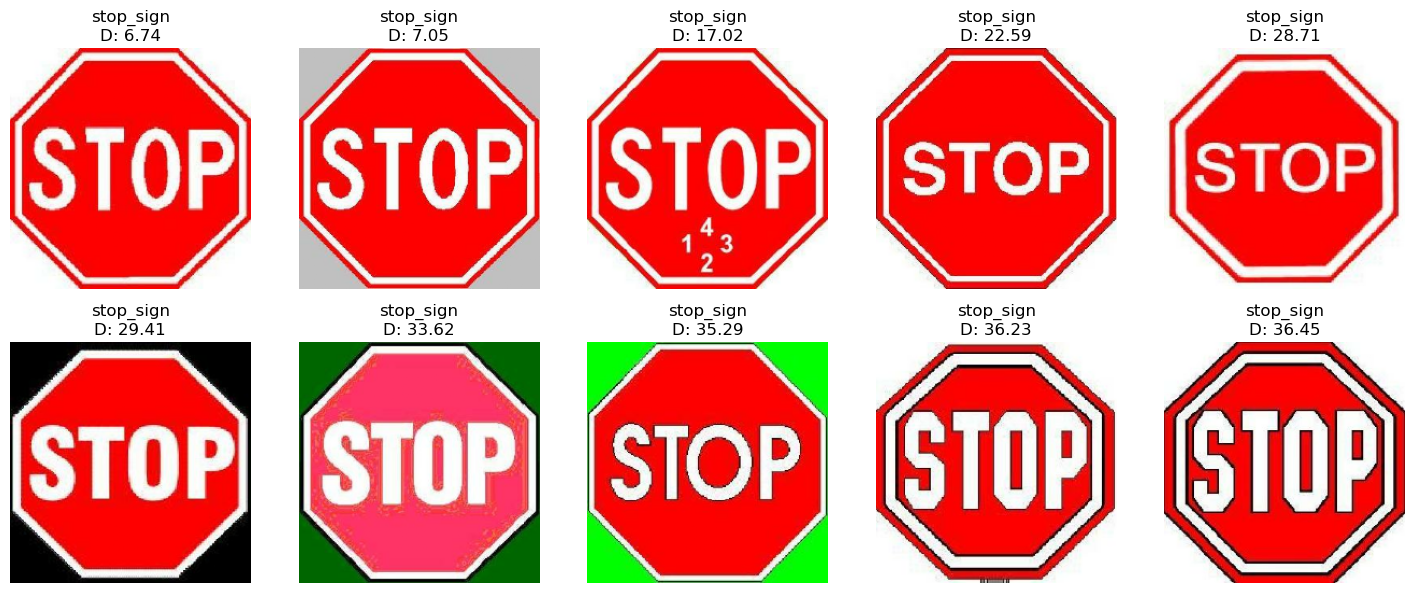

In [13]:
# Recuperar las imágenes de los vecinos más cercanos usando los índices
etiquetas_parecidas = [train_labels_flat[i] for i in indices.flatten()]
imagenes_parecidas = [train_imgenes_flat[i] for i in indices.flatten()]
plt.figure(figsize=(18, 7))  # Ajustar el tamaño de la figura
for i, _ in enumerate(imagenes_parecidas):
    plt.subplot(2, 5, i + 1)
    plt.imshow(imagenes_parecidas[i])
    plt.title("" + nombre_clases[etiquetas_parecidas[i]] + "\nD: " + str(round(distances[0][i], 2)))
    plt.axis('off')
plt.show()